In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.signal import butter, filtfilt
import os
from pathlib import Path
from argparse import ArgumentParser
from shutil import copyfile
import csv
import cv2

# Checking plots if something goes wrong

In [3]:
def bandpass_filter_for_plot(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def bandpass_magnitude_and_plot_v2(data, lowcut, highcut, fs, threshold):
    # Apply bandpass filter
    filtered_x = bandpass_filter_for_plot(data['x'], lowcut, highcut, fs)
    filtered_y = bandpass_filter_for_plot(data['y'], lowcut, highcut, fs)
    filtered_z = bandpass_filter_for_plot(data['z'], lowcut, highcut, fs)

    # Calculate magnitude
    magnitude = np.sqrt(filtered_x**2 + filtered_y**2 + filtered_z**2)
    avg_magnitude = np.mean(magnitude)
    
    # Detect fast movements based on threshold
    fast_movements_indices = np.asarray(np.where(magnitude > threshold)[0])

    # Plot raw data
    plt.figure(figsize=(10, 6))
    plt.plot(data['x'], label='x')
    plt.plot(data['y'], label='y')
    plt.plot(data['z'], label='z')
    plt.grid(True)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Raw Data (x, y, z)')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_x, label='Filtered x')
    plt.plot(filtered_y, label='Filtered y')
    plt.plot(filtered_z, label='Filtered z')
    plt.grid(True)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Filtered Data (x, y, z)')
    plt.legend()
    plt.show()

    # Plot magnitude
    plt.figure(figsize=(10, 6))
    plt.axhline(threshold, color='red', linestyle='--')
    plt.plot(magnitude, label='Magnitude')
    plt.xlabel('Index')
    plt.ylabel('Magnitude')
    plt.title('Magnitude after Band-Pass Filter')
    plt.legend()
    plt.show()
    
    if len(fast_movements_indices)>=1:
        start = fast_movements_indices[0]
        end = fast_movements_indices[-1]
        # Plot raw data with fast movements marked
        plt.figure(figsize=(10, 6))
        plt.plot(data['x'], label='x')
        plt.plot(data['y'], label='y')
        plt.plot(data['z'], label='z')
        plt.axvline(start, color='red', linestyle='--')
        plt.axvline(end, color='red', linestyle='--')
        plt.grid(True)
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title('Raw Data with Fast Movements Marked (x, y, z)')
        plt.legend()
        plt.show()
        
    else:
        start=len(data)
        end=len(data)
        print("No Fast Movements Detected")

In [4]:
df = pd.read_csv("Datas/71aZZ_176_20/2024-06-17_17-23-31/measurement.csv")
df = df.drop(len(df)-1, axis=0)
for col in df.columns:
    df[col] = pd.to_numeric(df[col])
df_x = pd.DataFrame(df["x"])

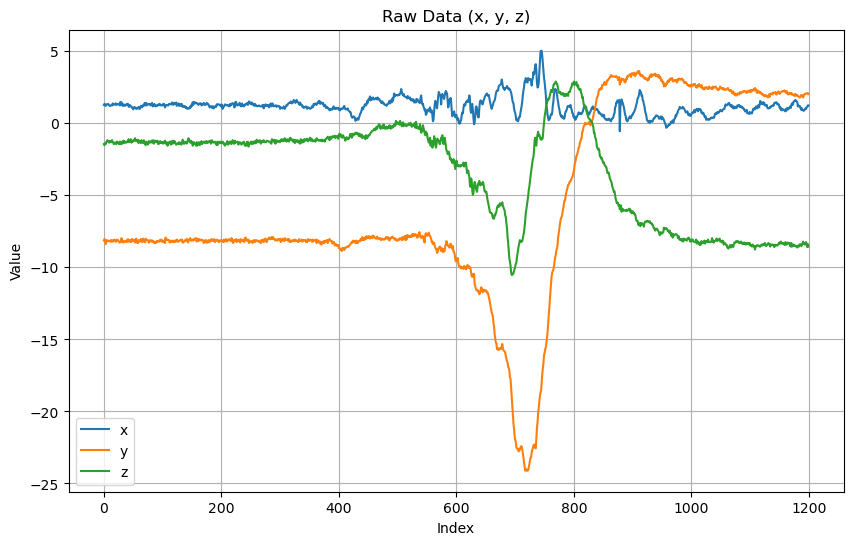

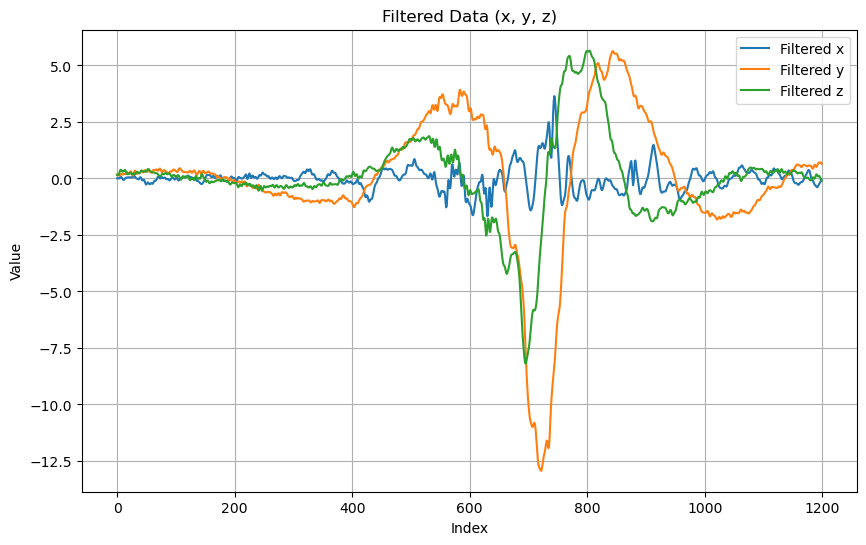

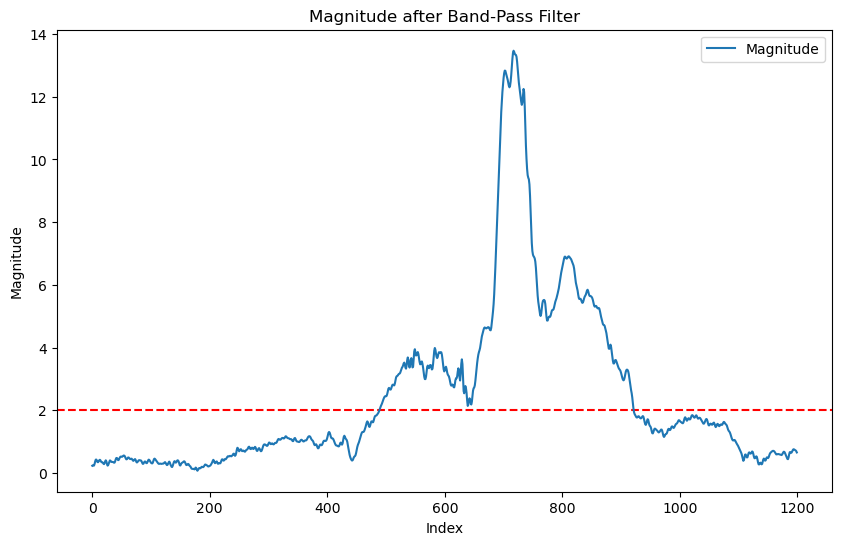

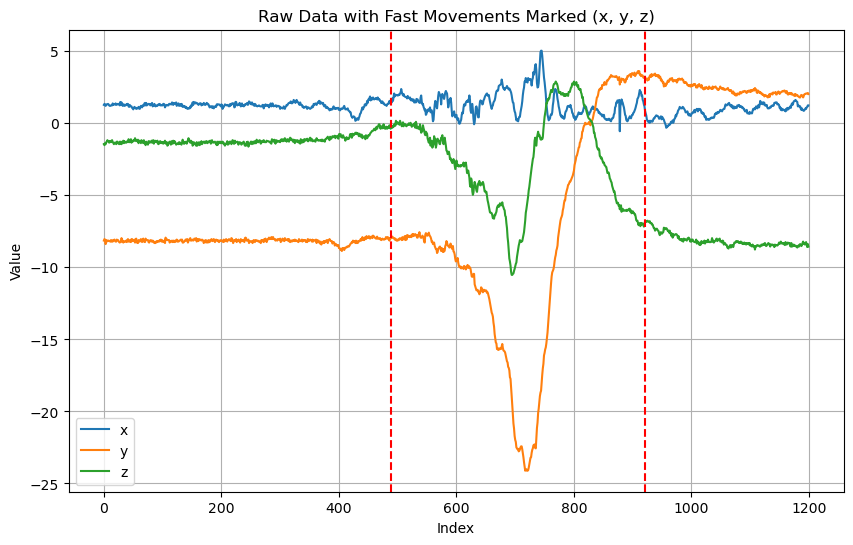

In [5]:
bandpass_magnitude_and_plot_v2(df, lowcut=0.1, highcut=10, fs=50, threshold=2)

# Scan and Filter

In [7]:
# Parameter
threshold = 17

In [8]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def bandpass_magnitude_and_plot(data, lowcut, highcut, fs, threshold):
    # Apply bandpass filter
    filtered_x = bandpass_filter(data['x'], lowcut, highcut, fs)
    filtered_y = bandpass_filter(data['y'], lowcut, highcut, fs)
    filtered_z = bandpass_filter(data['z'], lowcut, highcut, fs)

    # Calculate magnitude
    magnitude = np.sqrt(filtered_x**2 + filtered_y**2 + filtered_z**2)
    avg_magnitude = np.mean(magnitude)
    
    # Detect fast movements based on threshold
    fast_movements_indices = np.asarray(np.where(magnitude > threshold)[0])
    
    if len(fast_movements_indices)>=1:
        start = fast_movements_indices[0]
        end = fast_movements_indices[-1]
        
    else:
        return int(0),int(0)
        
    return start,end

In [9]:
def order_points(pts):
    try:
        pts = np.reshape(pts, (4, 2))
    except:
        return (-1,-1)

    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect
def fitler_sacks(contours):
    sacks = list()
    mean = 0
    for index in range(1, len(contours)):
        cnt = contours[index]
        area = cv2.contourArea(cnt)
        mean = (mean + area) / 2

        if index == 1:
            mean = area

        if area <= mean / 2:
            break

        if area < TOO_SMALL:
            break

        sacks.append(cnt)

    return sacks
def find_field(image: Path) -> list[tuple[float, float]]:
    img = cv2.imread(str(image))

    imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(imgray, 127, 255, 0)

    contours, hierarchy = cv2.findContours(
        thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    df = pd.DataFrame(
        hierarchy[0],
        columns=["nextSameLevel", "prviousSameLevel", "FirstChild", "Parent"],
    )
    fieldIdx = df.groupby("Parent").count().idxmax().nextSameLevel
    field = contours[fieldIdx]
    x, y, w, h = cv2.boundingRect(field)
    rect = np.array([[0, 0], [w, 0], [w, h], [0, h]], np.float32)
    epsilon = 0.1 * cv2.arcLength(field, True)
    approx = cv2.approxPolyDP(field, epsilon, True)
    
    if len(approx) != 4:
        return (-1,-1)
        
    rect2 = order_points(approx)

    m = cv2.getPerspectiveTransform(rect2, rect)

    dst = cv2.warpPerspective(img, m, (int(w), int(h)))
    dst = cv2.resize(dst, (int(w), int(w)), cv2.INTER_AREA)

    imgray = cv2.cvtColor(dst, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(imgray, 140, 255, 0)
    contours, hierarchy = cv2.findContours(
        thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    field_width = w
    sacks = fitler_sacks(contours)
    positions = []

    for sack in sacks:
        x, y, w, h = cv2.boundingRect(sack)
        center = (x + w / 2, y + h / 2)
        positions.append((center[0] / field_width * 2, center[1] / field_width * 2))

    return positions

In [10]:
main_directory = "Datas"
TOO_SMALL = 50
final_df = pd.DataFrame(columns=["throw","x","y","z","position"])

In [11]:
i=0
start_end_max_length = 0
start_end_min_length = 1200
start_end_max_length_file = ""
start_end_min_length_file = ""
for listthrowers in os.listdir(main_directory):
    for throwers in os.listdir(main_directory+"/"+listthrowers):
        if throwers=="Info.txt":
            continue
        else:
            for throw in os.listdir(main_directory+"/"+listthrowers+"/"+throwers):
                if throw.endswith(".jpg"):
                    file_path_img=os.path.join(main_directory,listthrowers, throwers,throw)
                    pos = find_field(file_path_img)
                elif throw.endswith(".csv"):
                    file_path=os.path.join(main_directory,listthrowers, throwers,throw)
                    real_df = pd.read_csv(file_path)
                    real_df = real_df.drop((len(real_df)-1), axis=0)
                    for col in real_df.columns:
                        real_df[col] = pd.to_numeric(real_df[col])
                    start, end = bandpass_magnitude_and_plot(real_df, lowcut=0.1, highcut=10, fs=50, threshold=2)
                    if (end-start) > start_end_max_length:
                        start_end_max_length = end-start
                        start_end_max_length_file = file_path
                    if ((end-start) < start_end_min_length) & (end!=start):
                        start_end_min_length = end-start
                        start_end_min_length_file = file_path
                    real_df = real_df[start:end]
                    real_df_x = np.array(real_df["x"])
                    real_df_y = np.array(real_df["y"])
                    real_df_z = np.array(real_df["z"])
                    final_df["x"][i] = real_df_x
                    final_df["y"][i] = real_df_y
                    final_df["z"][i] = real_df_z
                    new_row = pd.DataFrame({"throw":file_path,"x": [real_df_x], "y": [real_df_y], "z": [real_df_z], "position": [pos]})
                    final_df = pd.concat([final_df, new_row], ignore_index=True)
                    i=i+1
                else:
                    continue

In [12]:
final_df

,throw,x,y,z,position
0,Datas\71aZZ_176_20\2024-06-17_17-23-31\measure...,"[1.55250001, 1.449000001, 1.724999905, 1.55250...","[-7.934999943, -7.934999943, -7.865999699, -7....","[-0.206999987, -0.24149999, -0.310499996, -0.1...","[(1.48559670781893, 1.6310013717421126)]"
1,Datas\71aZZ_176_20\2024-06-17_17-25-40\measure...,"[1.31099999, 1.518000007, 1.690499902, 1.79399...","[-8.45249939, -8.418000221, -8.555999756, -8.5...","[-0.689999998, -0.689999998, -0.48299998, -0.5...","[(1.5130315500685871, 1.0617283950617284)]"
2,Datas\71aZZ_176_20\2024-06-27_13-34-09\measure...,"[0.172499999, 0.275999993, 0.413999975, 0.3449...","[-7.865999699, -8.00399971, -7.831499577, -7.9...","[-1.966499925, -2.000999928, -1.587000012, -1....","[(1.2315068493150685, 1.621917808219178)]"
3,Datas\71aZZ_176_20\2024-06-27_13-34-44\measure...,"[-0.413999975, -0.793500006, -0.655499995, -0....","[-8.038499832, -7.900499821, -7.693500042, -7....","[-1.724999905, -1.31099999, -1.79399991, -1.34...","[(1.33013698630137, 1.3520547945205479)]"
4,Datas\71aZZ_176_20\2024-06-27_13-35-04\measure...,"[-0.379500002, -0.034499999, 0.24149999, 0.862...","[-7.65899992, -7.65899992, -7.520999908, -7.79...","[-1.276499987, -1.276499987, -1.138499975, -1....","[(1.082191780821918, 0.8849315068493151)]"
...,...,...,...,...,...
157,Datas\Wb0LQ_167_22\2024-07-01_11-01-20\measure...,"[-1.966499925, -1.862999916, -1.897499919, -1....","[-8.00399971, -7.900499821, -7.900499821, -7.8...","[-1.414499998, -1.31099999, -1.518000007, -1.4...","[(0.42054794520547945, 1.2315068493150685)]"
158,Datas\Wb0LQ_167_22\2024-07-01_11-01-45\measure...,"[-1.31099999, -1.345499992, -1.345499992, -1.2...","[-8.279999733, -8.00399971, -8.418000221, -8.3...","[-0.551999986, -0.7245, -0.448499978, -0.44849...","[(0.1646090534979424, 1.149519890260631)]"
159,Datas\Wb0LQ_167_22\2024-07-01_11-02-14\measure...,"[-1.483500004, -1.414499998, -1.55250001, -1.3...","[-8.072999954, -8.107500076, -8.210999489, -8....","[-0.965999961, -0.655499995, -0.689999998, -0....","[(1.244170096021948, 1.0631001371742113)]"
160,Datas\Wb0LQ_167_22\2024-07-01_11-02-58\measure...,"[-0.965999961, -0.965999961, -0.931499958, -0....","[-8.418000221, -8.279999733, -8.383500099, -8....","[-0.206999987, -0.137999997, -0.172499999, -0....","[(1.4301369863013698, 1.1123287671232878)]"


In [13]:
indexes_to_remove = final_df.index[final_df["position"]==(-1,-1)].to_list()
final_df_removed = final_df.drop(indexes_to_remove, axis=0)

indexes_to_remove2 = final_df_removed.index[final_df_removed["x"].apply(lambda x: len(x) == 0)].to_list()
final_df_removed = final_df_removed.drop(indexes_to_remove2, axis=0)

In [14]:
# Define the columns to pad
columns_to_pad = ["x", "y", "z"]

for index, row in final_df_removed.iterrows():
    for col in columns_to_pad:
        array = row[col]
        while len(array) < start_end_max_length:
            array = np.append(array, 0)
        final_df_removed.at[index, col] = array

In [15]:
final_df_removed

,throw,x,y,z,position
0,Datas\71aZZ_176_20\2024-06-17_17-23-31\measure...,"[1.55250001, 1.449000001, 1.724999905, 1.55250...","[-7.934999943, -7.934999943, -7.865999699, -7....","[-0.206999987, -0.24149999, -0.310499996, -0.1...","[(1.48559670781893, 1.6310013717421126)]"
1,Datas\71aZZ_176_20\2024-06-17_17-25-40\measure...,"[1.31099999, 1.518000007, 1.690499902, 1.79399...","[-8.45249939, -8.418000221, -8.555999756, -8.5...","[-0.689999998, -0.689999998, -0.48299998, -0.5...","[(1.5130315500685871, 1.0617283950617284)]"
2,Datas\71aZZ_176_20\2024-06-27_13-34-09\measure...,"[0.172499999, 0.275999993, 0.413999975, 0.3449...","[-7.865999699, -8.00399971, -7.831499577, -7.9...","[-1.966499925, -2.000999928, -1.587000012, -1....","[(1.2315068493150685, 1.621917808219178)]"
3,Datas\71aZZ_176_20\2024-06-27_13-34-44\measure...,"[-0.413999975, -0.793500006, -0.655499995, -0....","[-8.038499832, -7.900499821, -7.693500042, -7....","[-1.724999905, -1.31099999, -1.79399991, -1.34...","[(1.33013698630137, 1.3520547945205479)]"
4,Datas\71aZZ_176_20\2024-06-27_13-35-04\measure...,"[-0.379500002, -0.034499999, 0.24149999, 0.862...","[-7.65899992, -7.65899992, -7.520999908, -7.79...","[-1.276499987, -1.276499987, -1.138499975, -1....","[(1.082191780821918, 0.8849315068493151)]"
...,...,...,...,...,...
157,Datas\Wb0LQ_167_22\2024-07-01_11-01-20\measure...,"[-1.966499925, -1.862999916, -1.897499919, -1....","[-8.00399971, -7.900499821, -7.900499821, -7.8...","[-1.414499998, -1.31099999, -1.518000007, -1.4...","[(0.42054794520547945, 1.2315068493150685)]"
158,Datas\Wb0LQ_167_22\2024-07-01_11-01-45\measure...,"[-1.31099999, -1.345499992, -1.345499992, -1.2...","[-8.279999733, -8.00399971, -8.418000221, -8.3...","[-0.551999986, -0.7245, -0.448499978, -0.44849...","[(0.1646090534979424, 1.149519890260631)]"
159,Datas\Wb0LQ_167_22\2024-07-01_11-02-14\measure...,"[-1.483500004, -1.414499998, -1.55250001, -1.3...","[-8.072999954, -8.107500076, -8.210999489, -8....","[-0.965999961, -0.655499995, -0.689999998, -0....","[(1.244170096021948, 1.0631001371742113)]"
160,Datas\Wb0LQ_167_22\2024-07-01_11-02-58\measure...,"[-0.965999961, -0.965999961, -0.931499958, -0....","[-8.418000221, -8.279999733, -8.383500099, -8....","[-0.206999987, -0.137999997, -0.172499999, -0....","[(1.4301369863013698, 1.1123287671232878)]"


# Write it into a csv

In [17]:
def list_to_comma_separated_string(lst):
    return ','.join(map(str, lst))

# Check and convert 'position' column
def convert_position(pos):
    if isinstance(pos, list):
        return ','.join(f"({','.join(map(str, p))})" for p in pos)
    else:
        return str(pos)

In [18]:
# Apply the function to the relevant columns
out_df = final_df_removed.copy()

out_df['x'] = out_df['x'].apply(list_to_comma_separated_string)
out_df['y'] = out_df['y'].apply(list_to_comma_separated_string)
out_df['z'] = out_df['z'].apply(list_to_comma_separated_string)

out_df['position'] = out_df['position'].apply(convert_position)

# Save DataFrame to CSV
out_df.to_csv('output.csv', index=False)

# Checking the Outputted DataFrame

In [36]:
outputted_df = pd.read_csv("output.csv")
outputted_df

,throw,x,y,z,position
0,Datas\71aZZ_176_20\2024-06-17_17-23-31\measure...,"1.55250001,1.449000001,1.724999905,1.55250001,...","-7.934999943,-7.934999943,-7.865999699,-7.9349...","-0.206999987,-0.24149999,-0.310499996,-0.17249...","(1.48559670781893,1.6310013717421126)"
1,Datas\71aZZ_176_20\2024-06-17_17-25-40\measure...,"1.31099999,1.518000007,1.690499902,1.79399991,...","-8.45249939,-8.418000221,-8.555999756,-8.52149...","-0.689999998,-0.689999998,-0.48299998,-0.51749...","(1.5130315500685871,1.0617283950617284)"
2,Datas\71aZZ_176_20\2024-06-27_13-34-09\measure...,"0.172499999,0.275999993,0.413999975,0.34499999...","-7.865999699,-8.00399971,-7.831499577,-7.93499...","-1.966499925,-2.000999928,-1.587000012,-1.3109...","(1.2315068493150685,1.621917808219178)"
3,Datas\71aZZ_176_20\2024-06-27_13-34-44\measure...,"-0.413999975,-0.793500006,-0.655499995,-0.5864...","-8.038499832,-7.900499821,-7.693500042,-7.9004...","-1.724999905,-1.31099999,-1.79399991,-1.345499...","(1.33013698630137,1.3520547945205479)"
4,Datas\71aZZ_176_20\2024-06-27_13-35-04\measure...,"-0.379500002,-0.034499999,0.24149999,0.8624999...","-7.65899992,-7.65899992,-7.520999908,-7.796999...","-1.276499987,-1.276499987,-1.138499975,-1.3454...","(1.082191780821918,0.8849315068493151)"
...,...,...,...,...,...
151,Datas\Wb0LQ_167_22\2024-07-01_11-01-20\measure...,"-1.966499925,-1.862999916,-1.897499919,-1.8629...","-8.00399971,-7.900499821,-7.900499821,-7.83149...","-1.414499998,-1.31099999,-1.518000007,-1.48350...","(0.42054794520547945,1.2315068493150685)"
152,Datas\Wb0LQ_167_22\2024-07-01_11-01-45\measure...,"-1.31099999,-1.345499992,-1.345499992,-1.20749...","-8.279999733,-8.00399971,-8.418000221,-8.34899...","-0.551999986,-0.7245,-0.448499978,-0.448499978...","(0.1646090534979424,1.149519890260631)"
153,Datas\Wb0LQ_167_22\2024-07-01_11-02-14\measure...,"-1.483500004,-1.414499998,-1.55250001,-1.31099...","-8.072999954,-8.107500076,-8.210999489,-8.1764...","-0.965999961,-0.655499995,-0.689999998,-0.5864...","(1.244170096021948,1.0631001371742113)"
154,Datas\Wb0LQ_167_22\2024-07-01_11-02-58\measure...,"-0.965999961,-0.965999961,-0.931499958,-0.9314...","-8.418000221,-8.279999733,-8.383500099,-8.1764...","-0.206999987,-0.137999997,-0.172499999,-0.3449...","(1.4301369863013698,1.1123287671232878)"
